Using Colab cache for faster access to the 'acdc-dataset' dataset.
Dataset in: /kaggle/input/acdc-dataset
Train volumes: /kaggle/input/acdc-dataset/ACDC_preprocessed/ACDC_training_volumes
Test volumes:  /kaggle/input/acdc-dataset/ACDC_preprocessed/ACDC_testing_volumes
Metadata caricati per 150 pazienti
Estrazione feature dal training set (pazienti 1-100)...
  100 pazienti utilizzabili
Estrazione feature dal test set (pazienti 101-150)...
  50 pazienti utilizzabili

Input binarizzato: 110 letterali (11 feature x 10 soglie)

=== Fase 1: training con selezione dell'epoca migliore ===
  epoca   1/60  train=0.613  val=0.250
  epoca   2/60  train=0.662  val=0.500
  epoca   3/60  train=0.925  val=0.650
  epoca   4/60  train=0.975  val=0.650
  epoca   5/60  train=0.938  val=0.600
  epoca   6/60  train=0.988  val=0.700
  epoca   7/60  train=1.000  val=0.800
  epoca   8/60  train=1.000  val=0.700
  epoca   9/60  train=1.000  val=0.750
  epoca  10/60  train=1.000  val=0.700
  epoca  11/60  train=

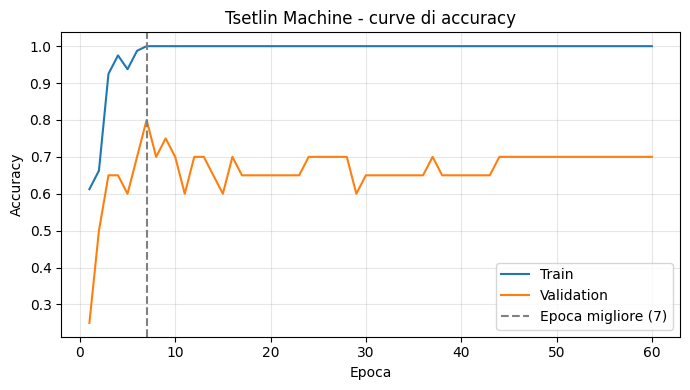


=== Valutazione finale sul test set (pazienti 101-150) ===
Test accuracy: 0.800

              precision    recall  f1-score   support

         NOR       0.90      0.90      0.90        10
         DCM       0.67      0.60      0.63        10
         HCM       0.90      0.90      0.90        10
        MINF       0.64      0.70      0.67        10
          RV       0.90      0.90      0.90        10

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50

Matrice di confusione (righe=vero, colonne=predetto):
[[9 0 0 0 1]
 [0 6 0 4 0]
 [1 0 9 0 0]
 [0 3 0 7 0]
 [0 0 1 0 9]]


In [7]:
# =====================================================================
# ACDC - classificazione con Tsetlin Machine (dataset Kaggle .h5)
# Incolla ogni blocco "# %%" in una cella di Colab, oppure esegui tutto.
# =====================================================================

# %% 0. Installazione (decommenta in Colab)
!pip install -q pyTsetlinMachine kagglehub h5py scikit-learn matplotlib

# %% 1. Import e download dataset
import os
import io
import csv
import glob
import urllib.request
from pathlib import Path

import numpy as np
import h5py
import kagglehub
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pyTsetlinMachine.tm import MultiClassTsetlinMachine

path = kagglehub.dataset_download("anhoangvo/acdc-dataset")
print("Dataset in:", path)


def find_dir(root, name):
    """Cerca ricorsivamente una cartella per nome (robusto al layout del download)."""
    for r, dirs, _ in os.walk(root):
        if name in dirs:
            return os.path.join(r, name)
    raise FileNotFoundError(f"Cartella '{name}' non trovata sotto {root}")


TRAIN_VOL_DIR = find_dir(path, "ACDC_training_volumes")
TEST_VOL_DIR = find_dir(path, "ACDC_testing_volumes")
print("Train volumes:", TRAIN_VOL_DIR)
print("Test volumes: ", TEST_VOL_DIR)

# %% 2. Metadata (patologia, frame ED/ES, altezza, peso) da CSV pubblico
TRAIN_CSV_URL = "https://huggingface.co/datasets/mathpluscode/ACDC/raw/main/train.csv"
TEST_CSV_URL = "https://huggingface.co/datasets/mathpluscode/ACDC/raw/main/test.csv"


def load_metadata(url):
    with urllib.request.urlopen(url) as resp:
        text = resp.read().decode("utf-8")
    meta = {}
    for row in csv.DictReader(io.StringIO(text)):
        pid = int(row["pid"].replace("patient", ""))
        meta[pid] = {
            "pathology": row["pathology"].strip(),
            "ed_frame": int(row["ed_frame"]),
            "es_frame": int(row["es_frame"]),
            "height": float(row["height"]),
            "weight": float(row["weight"]),
        }
    return meta


metadata = {}
metadata.update(load_metadata(TRAIN_CSV_URL))
metadata.update(load_metadata(TEST_CSV_URL))
print(f"Metadata caricati per {len(metadata)} pazienti")

# %% 3. Costanti e feature extraction dai file .h5
CLASSES = ["NOR", "DCM", "HCM", "MINF", "RV"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

FEATURE_NAMES = [
    "height", "weight", "bsa",
    "LVED", "LVES", "RVED", "RVES",
    "LVEF", "RVEF", "MYOED", "MYOES",
]

TRAIN_IDS = list(range(1, 101))
TEST_IDS = list(range(101, 151))

OUTPUT_DIR = Path.cwd() / "tm_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


def h5_frame_path(vol_dir, pid, frame):
    fp = os.path.join(vol_dir, f"patient{pid:03d}_frame{frame:02d}.h5")
    return fp if os.path.exists(fp) else None


def voxel_counts(label_arr):
    # Codici maschera: 1 = RV, 2 = MYO, 3 = LV
    return {
        "RV": int(np.sum(label_arr == 1)),
        "MYO": int(np.sum(label_arr == 2)),
        "LV": int(np.sum(label_arr == 3)),
    }


def bsa_mosteller(height_cm, weight_kg):
    return float(np.sqrt((height_cm * weight_kg) / 3600.0))


def extract_features(pid, vol_dir, meta):
    info = meta[pid]
    ed_fp = h5_frame_path(vol_dir, pid, info["ed_frame"])
    es_fp = h5_frame_path(vol_dir, pid, info["es_frame"])
    if ed_fp is None or es_fp is None:
        return None

    with h5py.File(ed_fp, "r") as f:
        ed_label = f["label"][:]
    with h5py.File(es_fp, "r") as f:
        es_label = f["label"][:]

    ed_c, es_c = voxel_counts(ed_label), voxel_counts(es_label)
    LVED, LVES = ed_c["LV"], es_c["LV"]
    RVED, RVES = ed_c["RV"], es_c["RV"]
    MYOED, MYOES = ed_c["MYO"], es_c["MYO"]
    LVEF = (LVED - LVES) / LVED if LVED > 0 else 0.0
    RVEF = (RVED - RVES) / RVED if RVED > 0 else 0.0

    height = info["height"]
    height_cm = height * 100.0 if height < 3.0 else height  # accetta metri o cm
    bsa = bsa_mosteller(height_cm, info["weight"])

    return np.array([
        height, info["weight"], bsa,
        LVED, LVES, RVED, RVES,
        LVEF, RVEF, MYOED, MYOES,
    ], dtype=np.float64)


def build_dataset(pid_range, vol_dir, meta):
    X, y, used = [], [], []
    for pid in pid_range:
        if pid not in meta:
            continue
        feats = extract_features(pid, vol_dir, meta)
        if feats is None:
            print(f"  [skip] patient{pid:03d}: file .h5 mancante per ED/ES")
            continue
        X.append(feats)
        y.append(CLASS_TO_IDX[meta[pid]["pathology"]])
        used.append(pid)
    return np.array(X), np.array(y), used


# %% 4. Binarizzazione (thermometer encoding)
def compute_bin_edges(X, n_bins):
    """Per ogni feature, n_bins soglie ai quantili equispaziati (solo dal train)."""
    qs = np.linspace(0, 1, n_bins + 2)[1:-1]
    return np.quantile(X, qs, axis=0).T  # shape (n_feature, n_bins)


def binarize_thermometer(X, edges):
    """x_ij > soglia_jk  ->  1. Output uint32 di shape (n, n_feature * n_bins)."""
    cols = []
    for j in range(X.shape[1]):
        for k in range(edges.shape[1]):
            cols.append((X[:, j] > edges[j, k]).astype(np.uint32))
    return np.stack(cols, axis=1)


# %% 5. Training con selezione dell'epoca migliore
def train_tm_with_best_epoch(
    X_train, y_train, X_val, y_val, X_trval, y_trval,
    n_clauses, T, s, max_epochs, seed,
):
    np.random.seed(seed)
    tm = MultiClassTsetlinMachine(n_clauses, T, s, weighted_clauses=True)

    train_accs, val_accs = [], []
    best_val_acc, best_epoch = -1.0, 0

    for epoch in range(max_epochs):
        # incremental=True: continua l'apprendimento invece di reinizializzare
        tm.fit(X_train, y_train, epochs=1, incremental=True)
        tr_acc = accuracy_score(y_train, tm.predict(X_train))
        va_acc = accuracy_score(y_val, tm.predict(X_val))
        train_accs.append(tr_acc)
        val_accs.append(va_acc)
        print(f"  epoca {epoch + 1:3d}/{max_epochs}  train={tr_acc:.3f}  val={va_acc:.3f}")
        if va_acc > best_val_acc:
            best_val_acc, best_epoch = va_acc, epoch

    print(f"\n>> Epoca migliore: {best_epoch + 1} (val_acc={best_val_acc:.3f})")
    print(f">> Ri-alleno da zero su train+val per {best_epoch + 1} epoche...")

    np.random.seed(seed)
    tm_final = MultiClassTsetlinMachine(n_clauses, T, s, weighted_clauses=True)
    for _ in range(best_epoch + 1):
        tm_final.fit(X_trval, y_trval, epochs=1, incremental=True)

    return tm_final, train_accs, val_accs, best_epoch


def plot_curves(train_accs, val_accs, best_epoch, out_path):
    epochs = np.arange(1, len(train_accs) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_accs, label="Train")
    plt.plot(epochs, val_accs, label="Validation")
    plt.axvline(best_epoch + 1, color="gray", linestyle="--",
                label=f"Epoca migliore ({best_epoch + 1})")
    plt.xlabel("Epoca")
    plt.ylabel("Accuracy")
    plt.title("Tsetlin Machine - curve di accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()


# %% 6. Main
def main():
    n_bins, n_clauses, T, s = 10, 300, 20, 5.0
    max_epochs, val_size, seed = 60, 0.2, 42

    print("Estrazione feature dal training set (pazienti 1-100)...")
    X_all, y_all, _ = build_dataset(TRAIN_IDS, TRAIN_VOL_DIR, metadata)
    print(f"  {len(y_all)} pazienti utilizzabili")

    print("Estrazione feature dal test set (pazienti 101-150)...")
    X_test_raw, y_test, _ = build_dataset(TEST_IDS, TEST_VOL_DIR, metadata)
    print(f"  {len(y_test)} pazienti utilizzabili")

    if len(y_all) == 0 or len(y_test) == 0:
        raise RuntimeError("Nessun paziente caricato: controlla i nomi dei file .h5 "
                           "(patientXXX_frameNN.h5) e i frame ED/ES.")

    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X_all, y_all, test_size=val_size, stratify=y_all, random_state=seed,
    )

    # Soglie calcolate solo sul train (niente leakage su val/test)
    edges = compute_bin_edges(X_train_raw, n_bins)
    X_train = binarize_thermometer(X_train_raw, edges)
    X_val = binarize_thermometer(X_val_raw, edges)
    X_trval = binarize_thermometer(X_all, edges)
    X_test = binarize_thermometer(X_test_raw, edges)

    y_train = y_train.astype(np.uint32)
    y_val = y_val.astype(np.uint32)
    y_trval = y_all.astype(np.uint32)
    y_test = y_test.astype(np.uint32)

    print(f"\nInput binarizzato: {X_train.shape[1]} letterali "
          f"({len(FEATURE_NAMES)} feature x {n_bins} soglie)")

    print("\n=== Fase 1: training con selezione dell'epoca migliore ===")
    tm_final, tr_accs, va_accs, best_epoch = train_tm_with_best_epoch(
        X_train, y_train, X_val, y_val, X_trval, y_trval,
        n_clauses=n_clauses, T=T, s=s, max_epochs=max_epochs, seed=seed,
    )

    plot_curves(tr_accs, va_accs, best_epoch, OUTPUT_DIR / "tm_accuracy_curve.png")

    print("\n=== Valutazione finale sul test set (pazienti 101-150) ===")
    test_pred = tm_final.predict(X_test)
    print(f"Test accuracy: {accuracy_score(y_test, test_pred):.3f}\n")
    print(classification_report(y_test, test_pred, target_names=CLASSES, zero_division=0))
    print("Matrice di confusione (righe=vero, colonne=predetto):")
    print(confusion_matrix(y_test, test_pred))


if __name__ == "__main__":
    main()